In [3]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

pd.set_option('display.max_rows', 500)


# Downloading dataset

In [4]:
df_train = pd.read_csv('data/train.csv')
X_test = pd.read_csv('data/test.csv')

# Data analysis

**df_train**

In [5]:
df_train.shape

(1460, 81)

In [6]:
df_train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [7]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
df_train.describe(include='object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


**X_test**

In [9]:
X_test.shape

(1459, 80)

In [10]:
X_test.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
5,1466,60,RL,75.0,10000,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
6,1467,20,RL,NaN,7980,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,500,3,2010,WD,Normal
7,1468,60,RL,63.0,8402,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
8,1469,20,RL,85.0,10176,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal
9,1470,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,4,2010,WD,Normal


In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
df_train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

**Visualizing the distribution of SalePrice**

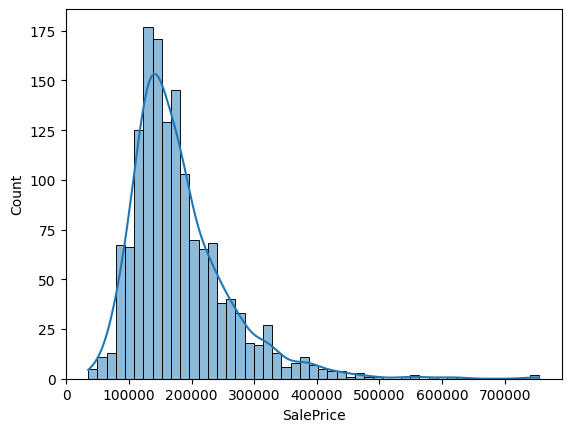

In [13]:
sns.histplot(df_train['SalePrice'], kde=True)
plt.show()

In [14]:
print(f"Skewness: {df_train['SalePrice'].skew()} \nKurtosis: {df_train['SalePrice'].kurtosis()}")

Skewness: 1.8828757597682129 
Kurtosis: 6.536281860064529


**Correlation matrix**

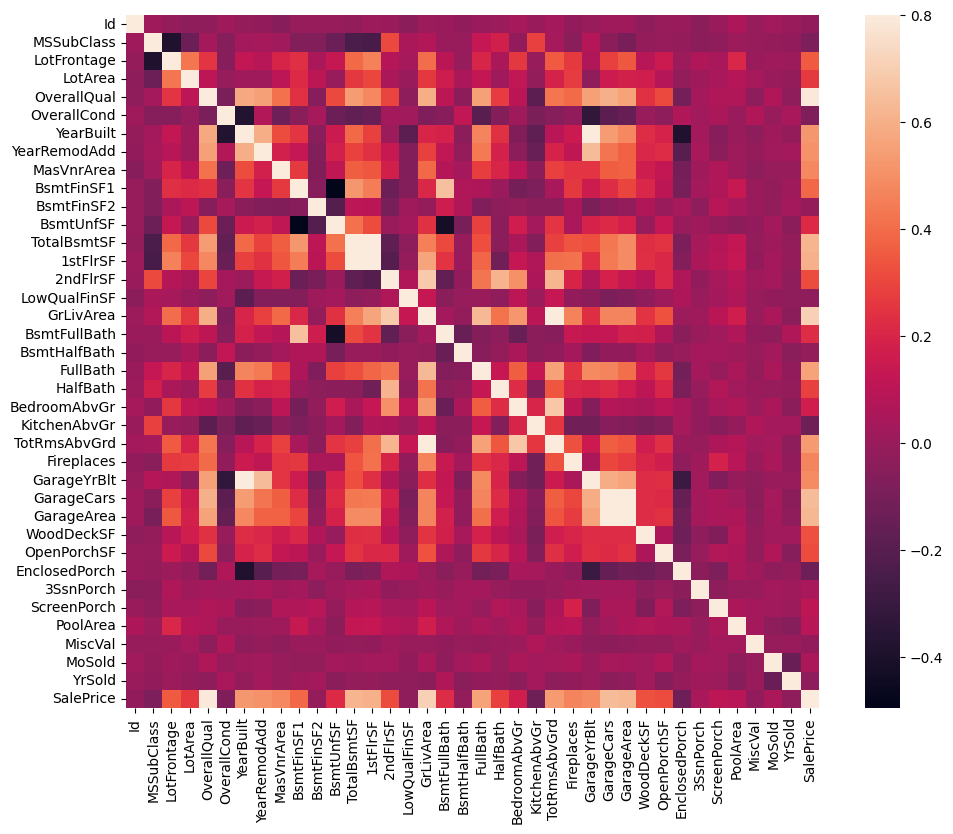

In [15]:
corrmat = df_train.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()

**Top 10 variables**

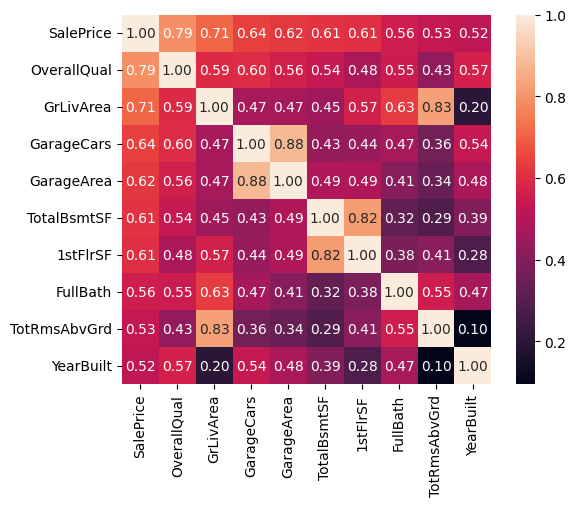

In [16]:
cols = corrmat.nlargest(10, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
heat = sns.heatmap(cm, cbar = True, annot = True, square = True, fmt = '.2f', yticklabels = cols.values, xticklabels = cols.values)

**Filling missing values**

In [17]:
columns_with_na = df_train.isna().sum() > 0
df_train.loc[:,columns_with_na.values].isna().sum()

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [18]:
for df in [df_train, X_test]:
    # Fill numeric columns with their mean value
    num_cols = df.select_dtypes(exclude='object').columns
    for col in num_cols:
        df[col].fillna(df[col].mean(), inplace=True)

    # Fill categorical columns with their mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_4218/800501910.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_4218/800501910.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [19]:
columns_with_na = df_train.isna().sum() > 0
df_train.loc[:,columns_with_na.values].isna().sum()

Series([], dtype: float64)

**Splitting df into target variable and features**

In [20]:
X = df_train.copy()
y = X.pop('SalePrice')

In [21]:
for df in [X, X_test]:
    for colname in df.select_dtypes("object"):
        df[colname], _ = df[colname].factorize()

# Feature engineering

In [22]:
X.drop('Id', axis=1, inplace=True)
X_test.drop('Id', axis=1, inplace=True)

**Discrete features**

In [23]:
discrete_features = list(X.select_dtypes(include='int').columns)
discrete_features

['MSSubClass',
 'MSZoning',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'Po

In [24]:
X.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [25]:
X.columns.isin(discrete_features)

array([ True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [26]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(
        X,
        y, 
        discrete_features = X.columns.isin(discrete_features)
    )
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)

mi_scores

OverallQual      5.797593e-01
Neighborhood     5.333487e-01
GarageArea       4.985240e-01
GrLivArea        4.330173e-01
YearBuilt        4.089402e-01
TotalBsmtSF      3.975893e-01
LotArea          3.930299e-01
GarageCars       3.629328e-01
ExterQual        3.329546e-01
KitchenQual      3.269802e-01
BsmtQual         3.159674e-01
GarageYrBlt      2.890156e-01
1stFlrSF         2.822281e-01
MSSubClass       2.766374e-01
YearRemodAdd     2.754394e-01
GarageFinish     2.561386e-01
FullBath         2.534593e-01
TotRmsAbvGrd     2.196471e-01
LotFrontage      1.985474e-01
Foundation       1.978019e-01
OpenPorchSF      1.927914e-01
HeatingQC        1.732324e-01
2ndFlrSF         1.686094e-01
Fireplaces       1.620372e-01
Exterior2nd      1.576496e-01
BsmtFinSF1       1.534648e-01
BsmtFinType1     1.345842e-01
Exterior1st      1.296147e-01
BsmtUnfSF        1.254734e-01
OverallCond      1.227335e-01
MSZoning         1.227022e-01
GarageType       1.225416e-01
WoodDeckSF       1.074832e-01
MasVnrArea

In [27]:
mi_scores.index

Index(['OverallQual', 'Neighborhood', 'GarageArea', 'GrLivArea', 'YearBuilt',
       'TotalBsmtSF', 'LotArea', 'GarageCars', 'ExterQual', 'KitchenQual',
       'BsmtQual', 'GarageYrBlt', '1stFlrSF', 'MSSubClass', 'YearRemodAdd',
       'GarageFinish', 'FullBath', 'TotRmsAbvGrd', 'LotFrontage', 'Foundation',
       'OpenPorchSF', 'HeatingQC', '2ndFlrSF', 'Fireplaces', 'Exterior2nd',
       'BsmtFinSF1', 'BsmtFinType1', 'Exterior1st', 'BsmtUnfSF', 'OverallCond',
       'MSZoning', 'GarageType', 'WoodDeckSF', 'MasVnrArea', 'HalfBath',
       'LotShape', 'HouseStyle', 'SaleCondition', 'FireplaceQu', 'SaleType',
       'BedroomAbvGr', 'BsmtExposure', 'CentralAir', 'MasVnrType',
       'Electrical', 'PavedDrive', 'BldgType', 'LandContour', 'BsmtCond',
       'EnclosedPorch', 'ExterCond', 'GarageCond', 'ScreenPorch',
       'KitchenAbvGr', 'Fence', 'Condition1', 'BsmtFullBath', 'GarageQual',
       'RoofStyle', 'Heating', 'BsmtFinType2', 'LotConfig', 'BsmtHalfBath',
       'Functional', 'Alle

In [28]:
mi_scores.values

array([5.79759339e-01, 5.33348673e-01, 4.98523969e-01, 4.33017326e-01,
       4.08940227e-01, 3.97589343e-01, 3.93029863e-01, 3.62932753e-01,
       3.32954567e-01, 3.26980232e-01, 3.15967370e-01, 2.89015637e-01,
       2.82228093e-01, 2.76637407e-01, 2.75439435e-01, 2.56138634e-01,
       2.53459301e-01, 2.19647069e-01, 1.98547439e-01, 1.97801863e-01,
       1.92791415e-01, 1.73232359e-01, 1.68609369e-01, 1.62037197e-01,
       1.57649643e-01, 1.53464794e-01, 1.34584219e-01, 1.29614745e-01,
       1.25473386e-01, 1.22733483e-01, 1.22702164e-01, 1.22541580e-01,
       1.07483198e-01, 9.22849465e-02, 8.95620362e-02, 8.73858683e-02,
       8.69543933e-02, 7.81987104e-02, 7.72927146e-02, 7.70657721e-02,
       7.22757519e-02, 6.81713188e-02, 6.36594349e-02, 5.41767724e-02,
       4.89236129e-02, 4.64598484e-02, 4.24660474e-02, 3.13828791e-02,
       2.77174780e-02, 2.32640665e-02, 2.17166719e-02, 2.10131179e-02,
       1.99169391e-02, 1.98367540e-02, 1.91225754e-02, 1.77225865e-02,
      

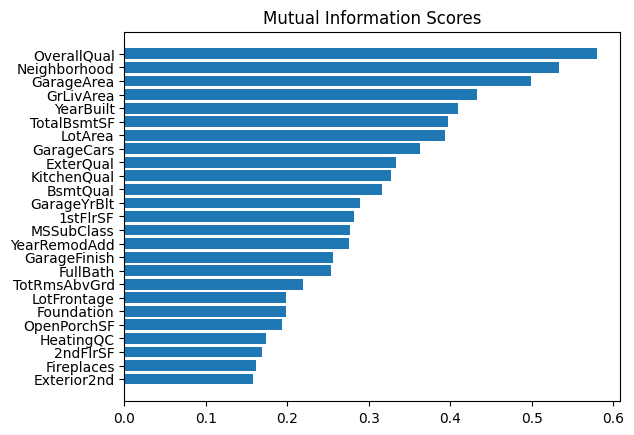

In [45]:
def plot_mi_scores(mi_scores):
    mi_scores = mi_scores.sort_values(ascending=True)
    width = np.arange(len(mi_scores))
    ticks = list(mi_scores.index)
    plt.barh(width, mi_scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plot_mi_scores(mi_scores.nlargest(25))

**Scaling data**

In [30]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X))
X_test = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

# Model

**Linear Regression**

In [31]:
linear_regression = LinearRegression()
linear_regression.fit(X, y)

LinearRegression()

In [32]:
linear_regression.score(X, y)

0.8461289056178266

In [33]:
y_pred_linear_regression = linear_regression.predict(X_test)
y_pred_linear_regression

/home/paolo/portfolio/python/house_prices/.venv/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([108013.20188118, 162748.39670627, 173226.93434813, ...,
       138793.54909248, 102270.43810391, 239010.05253619])

In [34]:
linear_regression_submission = pd.DataFrame({
        "Id": range(1461, 2920),
        "SalePrice": y_pred_linear_regression.round(2)
    })

linear_regression_submission

,Id,SalePrice
0,1461,108013.20
1,1462,162748.40
2,1463,173226.93
3,1464,193397.48
4,1465,203416.26
...,...,...
1454,2915,44127.34
1455,2916,57183.28
1456,2917,138793.55
1457,2918,102270.44


In [35]:
linear_regression_submission.to_csv('linear_regression_submission.csv', index = False)

**Random fortest**

In [36]:
random_forest = RandomForestRegressor(random_state=0)
random_forest.fit(X, y)

RandomForestRegressor(random_state=0)

In [37]:
random_forest.score(X, y)

0.9815965040907114

In [38]:
y_pred_random_forest = random_forest.predict(X_test)
y_pred_random_forest

/home/paolo/portfolio/python/house_prices/.venv/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


array([131724.  , 156450.25, 176261.44, ..., 155106.75, 113188.  ,
       234109.61])

In [39]:
random_forest_submission = pd.DataFrame({
        "Id": range(1461, 2920),
        "SalePrice": y_pred_random_forest
    })

random_forest_submission

,Id,SalePrice
0,1461,131724.00
1,1462,156450.25
2,1463,176261.44
3,1464,185249.80
4,1465,205985.90
...,...,...
1454,2915,81852.80
1455,2916,88262.37
1456,2917,155106.75
1457,2918,113188.00


In [40]:
random_forest_submission.to_csv('random_forest_submission.csv', index = False)